# UA Soft Tube - Scenario Number Sensitivity

Vary `n_scenarios` in the soft UA tube MPC and compare **total cost**, **operational cost**, **penalty**, and **runtime** on one full day (96 MPC steps). Results are saved to `UATMPC/results/`.

## Imports & Path Setup

In [1]:
from dataclasses import replace
from pathlib import Path
import sys
import time
import warnings

import pandas as pd

warnings.filterwarnings("ignore")

project_root = Path.cwd()
if project_root.name == "UATMPC":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from UATMPC import MPCConfig, Paths, PhysicalParams
from UATMPC.experiment import ExperimentRunner

## Experiment Configuration

Adjust `date`, `n_scenarios_values`, and `ww` here. Each scenario count gets its own `ExperimentRunner` so the scenario generator picks up the new `n_scenarios`.

In [2]:
paths = Paths.from_root(project_root)
base_config = MPCConfig()
params = PhysicalParams()

date = (7, 9)
date_tag = f"{date[0]:02d}_{date[1]:02d}"
ww = 0.1

n_scenarios_values = [25, 50, 100, 200, 500]
# n_scenarios_values = [15]

paths.results_dir.mkdir(parents=True, exist_ok=True)
output_csv = paths.results_dir / f"scenario_number_sensitivity_{date_tag}_{ww*100}.csv"
all_records = []

{
    "date": date,
    "ww": ww,
    "n_scenarios_values": n_scenarios_values,
    "output_csv": str(output_csv),
}

{'date': (7, 9),
 'ww': 0.1,
 'n_scenarios_values': [25, 50, 100, 200, 500],
 'output_csv': '/Users/liqi/Desktop/UATMPC codes/UATMPC/results/scenario_number_sensitivity_07_09_10.0.csv'}

## Helpers

In [3]:
def make_runner(n_scenarios: int) -> ExperimentRunner:
    """Build an ExperimentRunner with the requested scenario count."""
    config = replace(base_config, n_scenarios=n_scenarios)
    return ExperimentRunner(paths, config, params).setup()


def run_soft_ua_tube(n_scenarios: int) -> dict:
    """Run one full-day soft UA tube simulation for a given scenario count."""
    runner = make_runner(n_scenarios)
    started_at = time.time()
    try:
        result = runner.run_ua_tube_day(date, soft=True, ww=ww)
        return {
            "date_month": date[0],
            "date_day": date[1],
            "method": result["method"],
            "n_scenarios": n_scenarios,
            "ww": ww,
            "runtime": result["runtime"],
            "total_cost": result["total_cost"],
            "operational_cost": result["operational_cost"],
            "total_penalty": result["total_penalty"],
            "status": "ok",
            "error": "",
        }
    except Exception as exc:
        return {
            "date_month": date[0],
            "date_day": date[1],
            "method": "soft_ua_tube",
            "n_scenarios": n_scenarios,
            "ww": ww,
            "runtime": time.time() - started_at,
            "total_cost": None,
            "operational_cost": None,
            "total_penalty": None,
            "status": "error",
            "error": str(exc),
        }

## Run Experiments

Each `n_scenarios` value runs one full-day soft UA tube closed-loop simulation.

In [4]:
for n_scenarios in n_scenarios_values:
    print(f"Running soft UA tube for date {date}, n_scenarios = {n_scenarios}")
    record = run_soft_ua_tube(n_scenarios)
    all_records.append(record)
    if record["status"] == "ok":
        print(
            f"  total_cost={record['total_cost']:.2f}, "
            f"operational_cost={record['operational_cost']:.2f}, "
            f"penalty={record['total_penalty']:.2f}, "
            f"runtime={record['runtime']:.1f}s"
        )
    else:
        print(f"  failed: {record['error']}")

len(all_records)

Running soft UA tube for date (7, 9), n_scenarios = 25
Set parameter Username
Set parameter LicenseID to value 2711611
Academic license - for non-commercial use only - expires 2026-09-22
  total_cost=1018.61, operational_cost=1018.57, penalty=0.04, runtime=84.2s
Running soft UA tube for date (7, 9), n_scenarios = 50
  total_cost=990.12, operational_cost=990.12, penalty=0.00, runtime=157.7s
Running soft UA tube for date (7, 9), n_scenarios = 100
  total_cost=952.39, operational_cost=952.39, penalty=0.00, runtime=299.7s
Running soft UA tube for date (7, 9), n_scenarios = 200
  total_cost=928.90, operational_cost=928.90, penalty=0.00, runtime=689.5s
Running soft UA tube for date (7, 9), n_scenarios = 500
  total_cost=911.76, operational_cost=910.36, penalty=1.40, runtime=1750.1s


5

## Save Results

In [5]:
results_df = pd.DataFrame(all_records)
results_df.to_csv(output_csv, index=False)
output_csv

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/scenario_number_sensitivity_07_09_10.0.csv')

## Summary Table

Successful runs only, sorted by `n_scenarios` ascending.

In [6]:
summary_df = (
    results_df[results_df["status"] == "ok"]
    .sort_values("n_scenarios")
    .loc[:, ["n_scenarios", "total_cost", "operational_cost", "total_penalty", "runtime"]]
    .reset_index(drop=True)
)
summary_df

,n_scenarios,total_cost,operational_cost,total_penalty,runtime
0,25,1018.605747,1018.568208,0.037538,84.164275
1,50,990.118091,990.118091,0.000000,157.670776
2,100,952.390912,952.390912,0.000000,299.743897
3,200,928.903241,928.903241,0.000000,689.453196
4,500,911.762305,910.359384,1.402921,1750.106053


## Figure — Sensitivity on Scenario Number

Total cost versus scenario number.

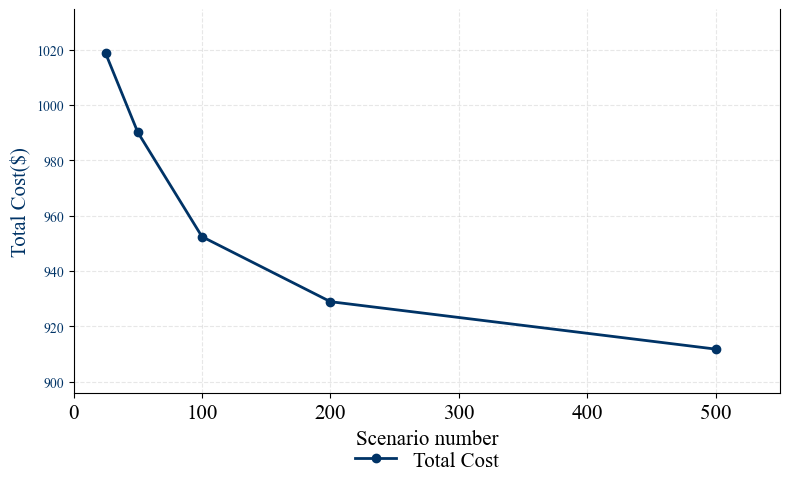

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/figures/scenario_number_sensitivity_07_09.pdf')

In [8]:
from matplotlib import pyplot as plt

plot_df = summary_df.copy()

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
plt.rcParams["mathtext.fontset"] = "stix"

x_values = plot_df["n_scenarios"]
color_cost = "#003366"

fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Scenario number", fontsize=15)
ax.set_ylabel("Total Cost($)", color=color_cost, fontsize=15)
ax.plot(
    x_values,
    plot_df["total_cost"],
    color=color_cost,
    marker="o",
    linewidth=2,
    label="Total Cost",
)
ax.tick_params(axis="y", labelcolor=color_cost)

cost_min, cost_max = plot_df["total_cost"].min(), plot_df["total_cost"].max()
cost_pad = max((cost_max - cost_min) * 0.15, 5)
ax.set_ylim(cost_min - cost_pad, cost_max + cost_pad)

ax.spines["top"].set_visible(False)
ax.set_xlim(0, 550)
ax.set_xticks([0, 100, 200, 300, 400, 500])
ax.tick_params(axis="x", labelsize=15)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    frameon=False,
    fontsize=15,
)

plt.tight_layout()

figures_dir = paths.root / "UATMPC" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
fig_path = figures_dir / f"scenario_number_sensitivity_{date_tag}.pdf"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
fig_path